<a href="https://colab.research.google.com/github/fatoufall737/atelier-scikit-learn-iot/blob/main/atelier_scikit_learn_iot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
uploaded = files.upload()  # sélectionne mesures_capteurs.csv depuis mon ordinateur

Saving mesures_capteurs.csv to mesures_capteurs.csv


In [3]:
df = pd.read_csv("mesures_capteurs.csv")
df.head()

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK


In [4]:
#explorer le dataframe
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    object 
 1   date_heure    605 non-null    object 
 2   id_capteur    605 non-null    object 
 3   batiment      605 non-null    object 
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    object 
dtypes: float64(4), object(5)
memory usage: 42.7+ KB


,temperature,humidite,pression,consommation
count,599.000000,600.00000,600.000000,600.000000
mean,24.878314,64.92620,1012.221900,208.675417
std,4.059576,10.76905,10.599042,72.243567
min,-18.500000,28.52000,850.000000,18.120000
25%,22.570000,58.17250,1006.790000,160.177500
50%,24.860000,65.37500,1012.855000,206.150000
75%,27.275000,71.61500,1017.827500,254.127500
max,58.700000,145.00000,1038.430000,875.000000


Partie 1 – Gestion des doublons
Avec Pandas,
1) vérifier l’existence de doublons dans df
2) le cas échéant, supprimer les doublons puis vérifier la suppression  

In [5]:
#Question 1 : vérifie l'existence de doublons dans df.
df.duplicated().sum()

np.int64(5)

In [6]:
#Question 2 : supprime les doublons puis vérifie la suppression.
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

Partie 2 – Sélection de y (cible) et X (caractéristiques)
1) Définir "etat" comme la cible ou valeur à prédire et "temperature", "humidite",
"pression" et "consommation" comme caractéristiques ou variables explicatives
2) Afficher les cinq premières lignes de X et de y
3) Quel est le type du problème de machine learning ?

In [7]:
#Question 1 : définis "etat" comme la cible (y) et "temperature", "humidite", "pression", "consommation" comme caractéristiques (X).
X = df[["temperature", "humidite", "pression", "consommation"]]
y = df["etat"]

In [9]:
#Question 2 : affiche les cinq premières lignes de X et de y.
X.head()

,temperature,humidite,pression,consommation
0,25.46,58.06,1008.95,287.28
1,24.00,79.73,993.39,116.20
2,25.82,54.47,1010.32,288.50
3,28.23,69.39,1019.62,136.65
4,20.58,53.80,1016.58,182.62


In [11]:
y.head()

,etat
0,OK
1,OK
2,OK
3,OK
4,OK


**3) Type du problème de Machine Learning**

C'est un problème de **classification** : la cible `y` (l'état du capteur) est une variable catégorielle avec un nombre limité de valeurs possibles (OK, ALERTE, ERREUR), pas une valeur numérique continue. On cherche à prédire à quelle catégorie appartient chaque mesure, pas à estimer un nombre.

Partie 3 – Découpage Train/Test
Diviser X en deux ensembles distincts : un pour l'entraînement (train) et un pour le test (test).
Avec les conditions suivantes : 20% des données serviront au test ; garantir la reproductibilité du
découpage ; conserver les mêmes proportions de classes dans l'ensemble de train et de test que
dans les données d'origine.



Consigne : diviser X en train/test, avec 20% pour le test, reproductibilité garantie, et proportions de classes conservées entre train et test.


In [14]:
# On retire les lignes où la cible (etat) est manquante, avant le découpage Train/Test
lignes_valides = y.notna()
X = X[lignes_valides]
y = y[lignes_valides]

print("Nombre de lignes après suppression des y manquants :", X.shape[0])

Nombre de lignes après suppression des y manquants : 596


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(476, 4) (120, 4)


Partie 4 – Gestion des valeurs manquantes
1) Vérifier l’existence de valeurs manquantes
2) Sélectionner SimpleImputer avec la médiane
3) Qu’est ce qui justifie le choix de la médiane ?
4) Trouver les paramètres (médianes) de l’imputeur sur X_train
5) Déterminer X_train_imputed et X_test_imputed, les transformés de X_train et X_test

In [18]:
X_train.isnull().sum()

,0
temperature,5
humidite,4
pression,5
consommation,3


In [19]:
#Question 2 : sélectionne SimpleImputer avec la médiane.
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

**3) Justification du choix de la médiane**

La médiane est préférée à la moyenne ici car elle est **moins sensible aux valeurs extrêmes (outliers)**. On sait déjà (ateliers précédents) que le jeu de données contient des anomalies très éloignées de la normale (ex. une température à -18°C ou 58°C). Si on utilisait la moyenne, ces valeurs extrêmes fausseraient le calcul et donneraient une valeur de remplacement peu représentative. La médiane reste stable face à ces anomalies, car elle ne dépend que de la position centrale des données triées, pas de leur amplitude.

In [20]:
#Question 4 : trouve les paramètres (médianes) de l'imputeur sur X_train.
imputer.fit(X_train)
imputer.statistics_

array([  24.9 ,   65.38, 1012.3 ,  206.59])

In [22]:
#Question 5 : détermine X_train_imputed et X_test_imputed.
X_train_imputed = imputer.transform(X_train)
X_test_imputed = imputer.transform(X_test)

print("Valeurs manquantes restantes dans X_train_imputed :", pd.DataFrame(X_train_imputed).isnull().sum().sum())
print("Valeurs manquantes restantes dans X_test_imputed  :", pd.DataFrame(X_test_imputed).isnull().sum().sum())

Valeurs manquantes restantes dans X_train_imputed : 0
Valeurs manquantes restantes dans X_test_imputed  : 0


Partie 5 – Mise à l'échelle
1) Sélectionner StandardScaler pour mettre à l’échelle les transformés de l’imputation
2) Qu’est ce qui justifie la standardisation ?
3) Trouver les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed
4) Déterminer X_train_scaled et X_test_scaled, les transformés de X_train_imputed et
X_test_imputed

In [23]:
#Question 1 : sélectionne StandardScaler pour mettre à l'échelle les transformés de l'imputation.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

**2) Justification de la standardisation**

Les 4 caractéristiques (température, humidité, pression, consommation) n'ont pas la même échelle de valeurs — par exemple, la pression tourne autour de 1000, alors que la température est autour de 20-30. Le modèle KNN (utilisé en Partie 6) calcule des **distances géométriques** entre les points pour faire ses prédictions : sans standardisation, la pression dominerait artificiellement le calcul de distance simplement parce que ses valeurs sont plus grandes, même si elle n'est pas plus importante que les autres variables. La standardisation ramène toutes les colonnes à la même échelle (moyenne 0, écart-type 1), pour que chaque variable ait un poids comparable dans le calcul.

In [24]:
#Question 3 : trouve les paramètres (moyennes et écart-types) du scaleur sur X_train_imputed.
scaler.fit(X_train_imputed)
print("Moyennes :", scaler.mean_)
print("Écarts-types :", scaler.scale_)

Moyennes : [  24.9637395    64.85044118 1012.07621849  210.15394958]
Écarts-types : [ 4.19303979 10.16279173 10.9941836  73.42092322]


In [25]:
#Question 4 : détermine X_train_scaled et X_test_scaled.
X_train_scaled = scaler.transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Moyenne après scaling (train) :", X_train_scaled.mean(axis=0).round(2))
print("Écart-type après scaling (train) :", X_train_scaled.std(axis=0).round(2))

Moyenne après scaling (train) : [-0.  0. -0.  0.]
Écart-type après scaling (train) : [1. 1. 1. 1.]


Partie 6 – Entrainement et prédiction d’un modèle
1) Sélectionner le modèle KNN (k plus proches voisins) avec 5, le nombre de voisins à prendre en
compte
2) Entrainer le modèle
3) Déterminer y_pred, la prédiction du modèle avec l’ensemble de test
4) Afficher quelques prédictions
5) Comparer ces prédictions avec les vraies valeurs

In [27]:
#Question 1 : sélectionne le modèle KNN avec 5 voisins.
from sklearn.neighbors import KNeighborsClassifier

modele = KNeighborsClassifier(n_neighbors=5)

In [28]:
#Question 2 : entraînement du modèle.
modele.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [29]:
#Question 3 : détermine y_pred, la prédiction du modèle avec l'ensemble de test
y_pred = modele.predict(X_test_scaled)

In [30]:
#Question 4 : affiche quelques prédictions.
print("Quelques prédictions :", y_pred[:10])

Quelques prédictions : ['OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK' 'OK']


In [31]:
#Question 5: compare ces prédictions avec les vraies valeurs.
comparaison = pd.DataFrame({
    "Vraie valeur": y_test.values[:10],
    "Prédiction": y_pred[:10]
})
comparaison

,Vraie valeur,Prédiction
0,OK,OK
1,OK,OK
2,OK,OK
3,OK,OK
4,ALERTE,OK
5,OK,OK
6,OK,OK
7,OK,OK
8,OK,OK
9,OK,OK


Partie 7 – Evaluation du modèle
1) Evaluer le modèle avec Accuracy puis afficher le résultat
2) Pourquoi Accuracy ne suffit pas toujours pour évaluer ?
3) Déterminer, afficher et commenter la matrice de confusion
4) Visualiser cette matrice avec Seaborn
5) Afficher et commenter le rapport de classificaton
6) Dans quel cas de problème de classification est-il plus indiqué d’évaluer avec la precision ; même
question avec recall; même question avec F1 score; même question avec accuracy

In [32]:
#Question 1 : évalue le modèle avec Accuracy puis affiche le résultat
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)

Accuracy : 0.9583333333333334


**2) Pourquoi l'accuracy ne suffit pas toujours**

L'accuracy peut être trompeuse quand les classes sont **déséquilibrées** — ce qui est le cas ici : la grande majorité des mesures sont "OK" (-94%), et très peu sont "ALERTE" ou "ERREUR" (moins de 6% à elles deux, comme vu en Partie 6 Matplotlib/Seaborn). Un modèle qui prédirait systématiquement "OK", sans jamais détecter une seule alerte ou erreur, obtiendrait quand même une accuracy très élevée (-94%), simplement parce que la classe majoritaire domine. L'accuracy seule ne dit donc pas si le modèle est réellement capable de détecter les cas rares (alertes, erreurs) — qui sont pourtant les plus importants à repérer dans ce contexte de surveillance de capteurs.

In [33]:
#Question 3 : détermine, affiche et commente la matrice de confusion.
from sklearn.metrics import confusion_matrix

matrice = confusion_matrix(y_test, y_pred, labels=modele.classes_)
print("Classes :", modele.classes_)
print(matrice)

Classes : ['ALERTE' 'ERREUR' 'OK']
[[  2   0   4]
 [  1   0   0]
 [  0   0 113]]


**3) Commentaire de la matrice de confusion**

- **OK** : les 113 mesures "OK" sont toutes correctement prédites — aucune erreur sur cette classe.
- **ALERTE** : sur 6 vraies alertes, seulement 2 sont correctement détectées ; les 4 autres sont classées à tort comme "OK" — le modèle manque donc la majorité des alertes réelles.
- **ERREUR** : la seule vraie "ERREUR" du jeu de test est mal classée (prédite comme "ALERTE") — le modèle ne détecte aucune erreur correctement.

Cette matrice confirme le problème évoqué à la question 2 : malgré une accuracy élevée (95.8%), le modèle est en réalité **très mauvais pour détecter les alertes et les erreurs**, qui sont pourtant les cas les plus critiques à repérer. Il se contente de prédire "OK" la plupart du temps, ce qui suffit à obtenir un bon score global à cause du déséquilibre des classes, mais échoue sur sa mission réelle (détecter les anomalies).

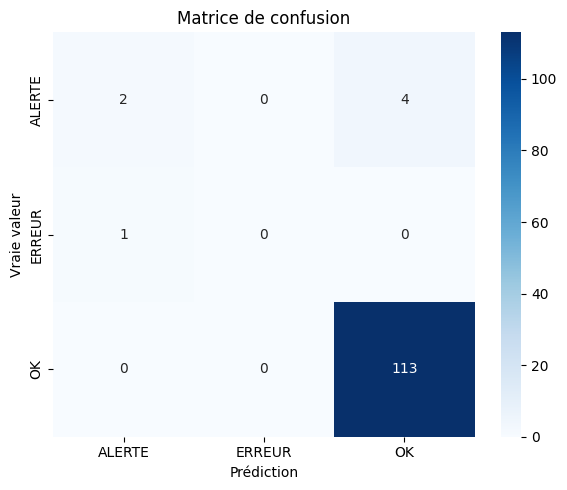

In [34]:
#Question 4 : visualise cette matrice avec seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(matrice, annot=True, fmt="d", cmap="Blues",
            xticklabels=modele.classes_, yticklabels=modele.classes_)
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Vraie valeur")
plt.tight_layout()
plt.show()

In [35]:
#Question 5 : affiche et commente le rapport de classification.
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      ALERTE       0.67      0.33      0.44         6
      ERREUR       0.00      0.00      0.00         1
          OK       0.97      1.00      0.98       113

    accuracy                           0.96       120
   macro avg       0.54      0.44      0.48       120
weighted avg       0.94      0.96      0.95       120



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**5) Commentaire du rapport de classification**

- **OK** : précision 0.97, rappel 1.00, F1-score 0.98 — le modèle est excellent sur cette classe, la plus représentée (113 exemples).
- **ALERTE** : précision 0.67, rappel 0.33, F1-score 0.44 — le modèle détecte seulement 1 alerte sur 3 (rappel faible), même si, quand il prédit "ALERTE", il a raison 2 fois sur 3 (précision correcte).
- **ERREUR** : précision, rappel et F1-score tous à 0 — le modèle ne détecte jamais cette classe, probablement car elle n'a qu'un seul exemple dans le jeu de test (support = 1), ce qui est trop peu pour que le modèle apprenne à la reconnaître.

*Note technique* : l'avertissement `UndefinedMetricWarning` apparaît car le modèle n'a jamais prédit "ERREUR" — la précision (qui se calcule sur les prédictions faites) est alors mathématiquement indéfinie (division par zéro), et scikit-learn la fixe à 0 par défaut.

Ce rapport confirme, avec des métriques précises, ce qu'on observait déjà sur la matrice de confusion : le modèle est fiable pour la classe majoritaire (OK), mais peu performant sur les classes rares (ALERTE, ERREUR) — un problème classique de **déséquilibre des classes**.

**6) Quand utiliser chaque métrique**

- **Précision** : utile quand le coût d'un **faux positif** est élevé — c'est-à-dire quand prédire "ALERTE" ou "ERREUR" à tort a des conséquences importantes (ex. déclencher une intervention coûteuse pour rien). On veut être sûr que quand le modèle prédit une anomalie, c'en est vraiment une.

- **Rappel (recall)** : utile quand le coût d'un **faux négatif** est élevé — c'est-à-dire quand rater une vraie anomalie est plus grave que se tromper en la signalant à tort. Dans notre contexte de surveillance de capteurs, c'est souvent le cas : mieux vaut vérifier une fausse alerte que laisser passer une vraie panne.

- **F1-score** : utile quand on veut un **équilibre** entre précision et rappel, sans privilégier l'un plus que l'autre — pratique quand les deux types d'erreurs (faux positifs et faux négatifs) ont un coût comparable, ou pour comparer facilement plusieurs modèles avec un seul chiffre par classe.

- **Accuracy** : utile uniquement quand les classes sont **équilibrées** (à peu près le même nombre d'exemples dans chaque catégorie). Dans notre cas (94% de "OK"), l'accuracy seule seraite trompeuse — c'est pour ça qu'on privilégie plutôt le rappel ou le F1-score sur les classes minoritaires (ALERTE, ERREUR) pour évaluer réellement la capacité du modèle à détecter les anomalies.

Partie 8 – Sauvegarde du modèle
1) Sauvegarder le modèle avec Joblib pour avoir models/modele_capteurs.joblib
2) Sauvegarder le modèle avec Pickle pour avoir models/modele_capteurs.pkl

In [36]:
#Question 1 : sauvegarde le modèle avec Joblib.
import os
os.makedirs("models", exist_ok=True)

import joblib
joblib.dump(modele, "models/modele_capteurs.joblib")
print("Modèle sauvegardé avec joblib.")

Modèle sauvegardé avec joblib.


In [37]:
#Question 2 (dernière de la Partie 8) : sauvegarde le modèle avec Pickle.
import pickle

with open("models/modele_capteurs.pkl", "wb") as fichier:
    pickle.dump(modele, fichier)
print("Modèle sauvegardé avec pickle.")

Modèle sauvegardé avec pickle.


Partie 9 – Chargement du modèle
1) Charger le modèle
2) Faire une prédiction avec une nouvelle mesure

In [38]:
#Question 1 : chargement du modèle.
modele_charge = joblib.load("models/modele_capteurs.joblib")
print("Modèle rechargé avec succès.")

Modèle rechargé avec succès.


In [39]:
#Question 2 (dernière question technique de l'atelier) : fais une prédiction avec une nouvelle mesure.
# Nouvelle mesure fictive : température, humidité, pression, consommation
nouvelle_mesure = pd.DataFrame({
    "temperature": [26.5],
    "humidite": [60.0],
    "pression": [1013.0],
    "consommation": [200.0]
})

# Important : appliquer les mêmes étapes de prétraitement que sur les données d'entraînement
nouvelle_mesure_imputed = imputer.transform(nouvelle_mesure)
nouvelle_mesure_scaled = scaler.transform(nouvelle_mesure_imputed)

prediction = modele_charge.predict(nouvelle_mesure_scaled)
print("État prédit pour cette nouvelle mesure :", prediction[0])

État prédit pour cette nouvelle mesure : OK


In [40]:
from google.colab import files
files.download("models/modele_capteurs.joblib")
files.download("models/modele_capteurs.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>